In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

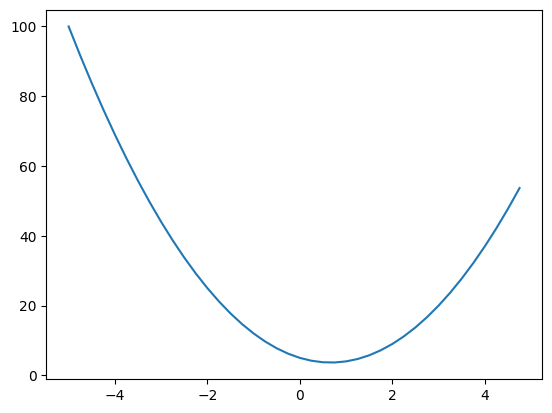

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.001
x = 3.0
(f(x + h) - f(x)) / h

14.00300000000243

In [6]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [8]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
            # += 是因为可能有多个路径到达同一个节点，所以需要累加
            # 例如：
            # a = Value(3.0, label='a')
            # b = a + a; b.label = 'b'
            # b.backward()
            # draw_dot(b)
        out._backward = _backward

        return out

    def __radd__(self, other):
        # support sum() and scalar + Value
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward

        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += out.grad * other * self.data ** (other - 1)
        out._backward = _backward

        return out

    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward

        return out
    
    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')

        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


# 小测试
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b
e.label = 'e'
d = e + c
d.label = 'd'
f = Value(-2.0, label='f')
L = d * f
L.label = 'L'


In [9]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [10]:
d._op

'+'

In [11]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

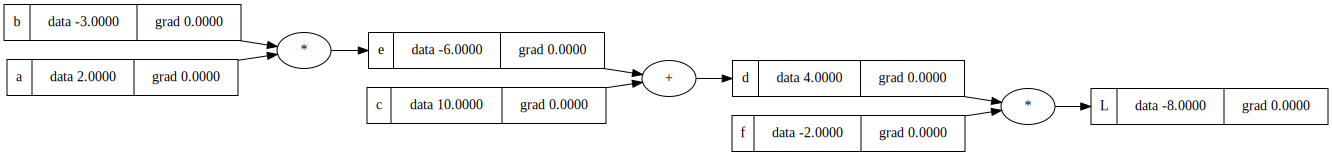

In [12]:
draw_dot(L)

In [13]:
L.grad = 1.0
f.grad = L.grad * d.data
d.grad = L.grad * f.data
c.grad = d.grad * 1.0
e.grad = d.grad * 1.0
a.grad = e.grad * b.data
b.grad = e.grad * a.data   

In [14]:
# 沿着梯度方向微调输入，导致输出变大
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
print(L.data)

-7.286496


In [15]:
def lol():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b
    e.label = 'e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'
    L1 = L.data
    
    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b
    e.label = 'e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

6.000000000021544


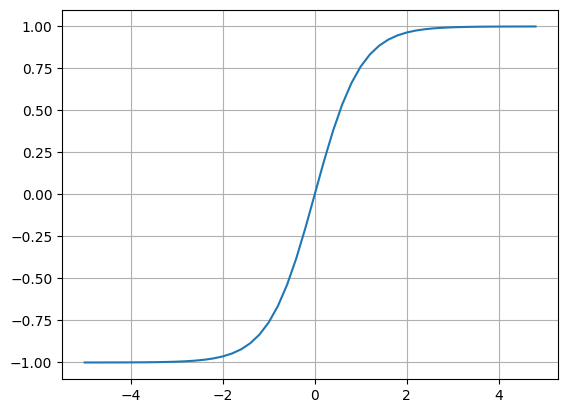

In [16]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid()


In [17]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# wights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


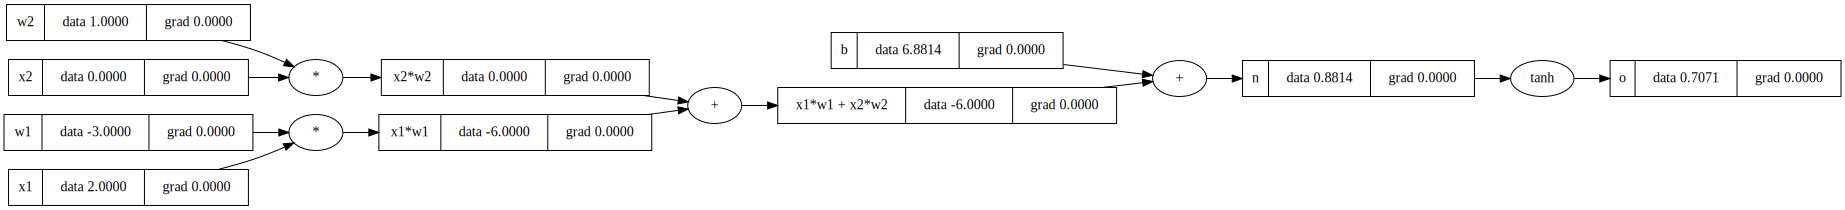

In [18]:
draw_dot(o)

In [19]:
o.backward()

In [20]:
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()

In [21]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [22]:
# o = n.tanh()
# do/dn = 1 - o**2
o.grad = 1.0
n.grad = o.grad * (1 - o.data**2)
x1w1x2w2.grad = n.grad * 1.0
b.grad = n.grad * 1.0
x1w1.grad = x1w1x2w2.grad * 1.0
w1.grad = x1w1.grad * x1.data
x1.grad = x1w1.grad * w1.data
x2w2.grad = x1w1x2w2.grad * 1.
w2.grad = x2w2.grad * x2.data
x2.grad = x2w2.grad * w2.data


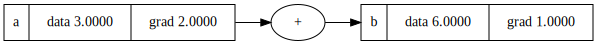

In [23]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

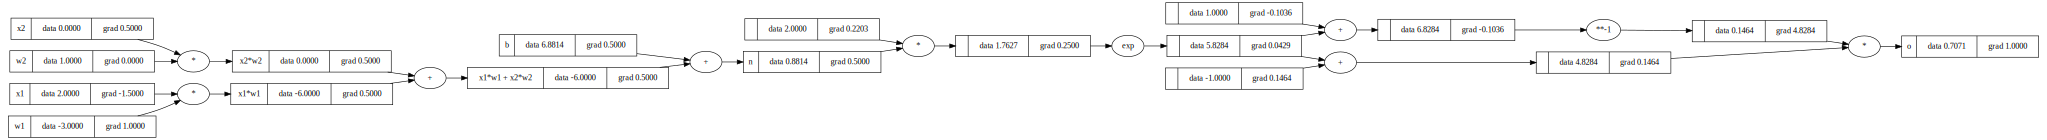

In [24]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# wights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh()
# -----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# -----
o.label = 'o'
o.backward()
draw_dot(o)

In [25]:
import torch
x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [26]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(np.random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(np.random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:                           # multi-layer perceptron
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [27]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=0.9786460756128769)

In [28]:
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

[Value(data=-0.9948341360324187),
 Value(data=0.9755888678280756),
 Value(data=0.8577179055548606)]

In [29]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.7715124491857597)

In [30]:
n.parameters()

[Value(data=-0.3195231095677682),
 Value(data=-0.8360479424601204),
 Value(data=-0.6764670039647969),
 Value(data=-0.9749184783837572),
 Value(data=-0.887800066166025),
 Value(data=-0.5731359857816867),
 Value(data=0.28215432919909533),
 Value(data=-0.6462244080834858),
 Value(data=-0.4210569211829218),
 Value(data=-0.5937323882544514),
 Value(data=0.385764439835246),
 Value(data=0.37567908620309787),
 Value(data=0.1975924054340057),
 Value(data=0.21282274278144997),
 Value(data=-0.29553316445266953),
 Value(data=-0.3966032467228233),
 Value(data=-0.3290893623433453),
 Value(data=-0.37382734599495215),
 Value(data=-0.1598089629401913),
 Value(data=-0.7927926480944008),
 Value(data=0.691089942701298),
 Value(data=-0.5041032228754714),
 Value(data=0.588574177888223),
 Value(data=-0.4449889452001634),
 Value(data=-0.4389499680687792),
 Value(data=-0.13275148271203552),
 Value(data=0.26351545908391527),
 Value(data=-0.928617110607493),
 Value(data=-0.5829713600588773),
 Value(data=0.620619

In [31]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, -1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.7715124491857597),
 Value(data=0.753177965427459),
 Value(data=0.7245776534397051),
 Value(data=0.7520782807862398)]

In [32]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=9.169785924083918)

In [33]:
loss.backward()

In [34]:
n.layers[0].neurons[0].w[0].grad

-0.03620309910016357

In [35]:
for k in range(30):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    # backward pass
    for p in n.parameters():
        p.grad = 0.0 # reset gradients to zero before backward pass
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 9.169785924083918
1 5.6032199859845235
2 2.8429427832298257
3 2.5942592910676803
4 2.355157958474542
5 2.112228610452418
6 1.8547877274420117
7 1.5906069585998388
8 1.3340217675958197
9 1.0970726658482084
10 0.8881136098729381
11 0.7121559134998147
12 0.5701607401650732
13 0.45917645070176183
14 0.3739734547043024
15 0.30889388221165415
16 0.2589622028351102
17 0.2202622299708864
18 0.18986781890251356
19 0.16565833851365103
20 0.1461033854577151
21 0.13009743259088763
22 0.11683176482636648
23 0.1057095347833012
24 0.09628543514568566
25 0.08822321968718172
26 0.08126567678687532
27 0.07521360890523335
28 0.0699109635623434
29 0.06523416157589072


In [36]:
ypred

[Value(data=0.8262036832130359),
 Value(data=-0.9699255262562327),
 Value(data=-0.9146105595475096),
 Value(data=-0.8361916628024629)]